<a href="https://colab.research.google.com/github/luisdavidmontero1016/luisdavidmontero1016/blob/main/Trabajo_Final_IC_Prueba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from IPython.core.display import display, HTML

encabezado_html = """
<div style="
    background: linear-gradient(to right, #006A71, #48A6A7);
    color: white;
    text-align: center;
    padding: 30px;
    font-size: 35px;
    font-weight: bold;
    border-radius: 12px;
    box-shadow: 3px 3px 10px rgba(0, 0, 0, 0.2);
    font-family: Arial, sans-serif;">
    📚 Trabajo Final  Modelo de clasificación 📚
    <br>

</div>
"""

display(HTML(encabezado_html))

In [ ]:
from IPython.core.display import display, HTML

encabezado_html = """
<div style="
    background: linear-gradient(to right, #006A71, #48A6A7);
    color: white;
    text-align: center;
    padding: 30px;
    font-size: 35px;
    font-weight: bold;
    border-radius: 12px;
    box-shadow: 3px 3px 10px rgba(0, 0, 0, 0.2);
    font-family: Arial, sans-serif;">
    📙Fase 1📙
    <br>

</div>
"""

display(HTML(encabezado_html))

# <font color='48A6A7'>**Librerias Necesarias**</font>

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import EfficientNetB0, ResNet50, MobileNetV2
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import gc

import tensorflow as tf

tf.config.run_functions_eagerly(True)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# <font color='48A6A7'>**Preparación del dataset**</font>


####**Descripción del problema:**

Clasificacion de mamiferos tales como buffalos, elefantes y hipopotamos

# <font color='48A6A7'>**Prepocesamiento**</font>



* Redimensionamiento de imágenes.
* Normalización.
* Con aumento de datos (data augmentation).
* Sin aumento de datos (No data augmentation)

# <font color='48A6A7'>**Rutas Imagenes**</font>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# <font color='48A6A7'>**Estructuras de las carpetas**</font>

    Trabajo_Final_IC/
        ├── entrenamiento/  
        │   ├── buffalo/  
        │   ├── elefante/  
        │   └── hipopotamo/  
        └── prueba/  
            ├── buffalo/  
            ├── elefante/  
            └── hipopotamo/  

In [ ]:
# =============================================
# 1.Configuración Global
# =============================================

# Antes de entrenar, libera memoria
gc.collect()

IMG_SIZE = (224, 224)  # Tamaño estándar para modelos preentrenados
BATCH_SIZE = 8        # Número de imágenes por lote
EPOCHS = 8          # Iteraciones de entrenamiento
NUM_CLASSES = 3        # 3 clases: buffalo, elefante, hipopótamo




In [ ]:
#Ruta a los datos
train_dir = '/content/drive/MyDrive/Colab Notebooks/Inteligencia_Computacional/Trabajo_Final_IC/entrenamiento'
test_dir = '/content/drive/MyDrive/Colab Notebooks/Inteligencia_Computacional/Trabajo_Final_IC/prueba'


In [ ]:
# Data Augmentation (solo para entrenamiento)
train_datagen = ImageDataGenerator(
    rescale=1./255,               # Normalización (píxeles de 0 a 1)
    rotation_range=20,            # Rotación aleatoria (±20°)
    width_shift_range=0.2,        # Desplazamiento horizontal (20%)
    height_shift_range=0.2,       # Desplazamiento vertical (20%)
    shear_range=0.2,              # Deformación angular
    zoom_range=0.2,               # Zoom aleatorio (80%-120%)
    horizontal_flip=True,         # Volteo horizontal aleatorio
    fill_mode='nearest',          # Rellena pixeles vacíos
    validation_split=0.2          # 20% de los datos de train para validación
)

In [ ]:
# Solo normalización para validación y test (sin aumento de datos)
val_test_datagen = ImageDataGenerator(rescale=1./255)


In [ ]:
# Generadores de datos
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,        # Redimensionamiento
    batch_size=BATCH_SIZE,
    class_mode='categorical',    # Clasificación multiclase
    subset='training'            # 80% para entrenamiento
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'          # 20% para validación
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False                # No mezclar para evaluación
)

# Nombres de las clases
class_names = list(train_generator.class_indices.keys())
print("Classes:", class_names)

Found 192 images belonging to 3 classes.
Found 47 images belonging to 3 classes.
Found 60 images belonging to 3 classes.
Classes: ['buffalo', 'elefante', 'hipopotamo']


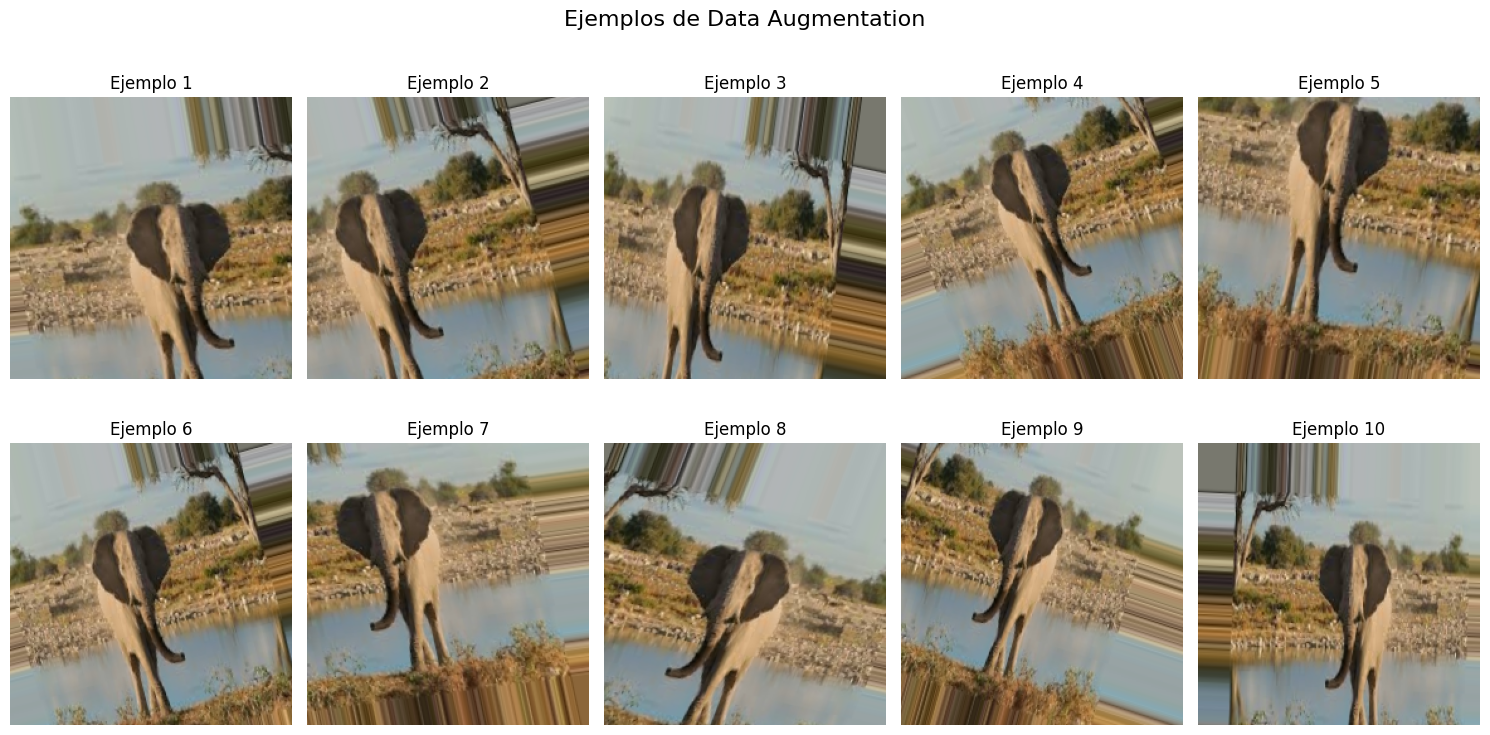

In [ ]:
# Cargar una imagen de ejemplo (debe estar en una de las carpetas de entrenamiento)
sample_image_path = '/content/drive/MyDrive/Colab Notebooks/Inteligencia_Computacional/Trabajo_Final_IC/entrenamiento/elefante/Elephant_76.jpg'
sample_image = load_img(sample_image_path, target_size=IMG_SIZE)
sample_image_array = img_to_array(sample_image)
sample_image_array = np.expand_dims(sample_image_array, axis=0)  # Añadir dimensión del batch

# Cargar una imagen de ejemplo (debe estar en una de las carpetas de entrenamiento)
sample_image_path = '/content/drive/MyDrive/Colab Notebooks/Inteligencia_Computacional/Trabajo_Final_IC/entrenamiento/elefante/Elephant_76.jpg'
sample_image = load_img(sample_image_path, target_size=IMG_SIZE)
sample_image_array = img_to_array(sample_image)
sample_image_array = np.expand_dims(sample_image_array, axis=0)  # Añadir dimensión del batch

# Crear un generador para visualizar aumentos
# Use train_datagen instead of augmentation_generator
augmented_images = train_datagen.flow(
    sample_image_array,
    batch_size=1  # Generar una imagen a la vez
)

# Visualizar 10 ejemplos de aumentos
plt.figure(figsize=(15, 8))
plt.suptitle("Ejemplos de Data Augmentation", fontsize=16)

for i in range(10):
    augmented_image = next(augmented_images)[0]  # Obtener la primera (y única) imagen del batch

    plt.subplot(2, 5, i+1)
    plt.imshow(augmented_image)
    plt.axis('off')
    plt.title(f"Ejemplo {i+1}")

plt.tight_layout()
plt.show()





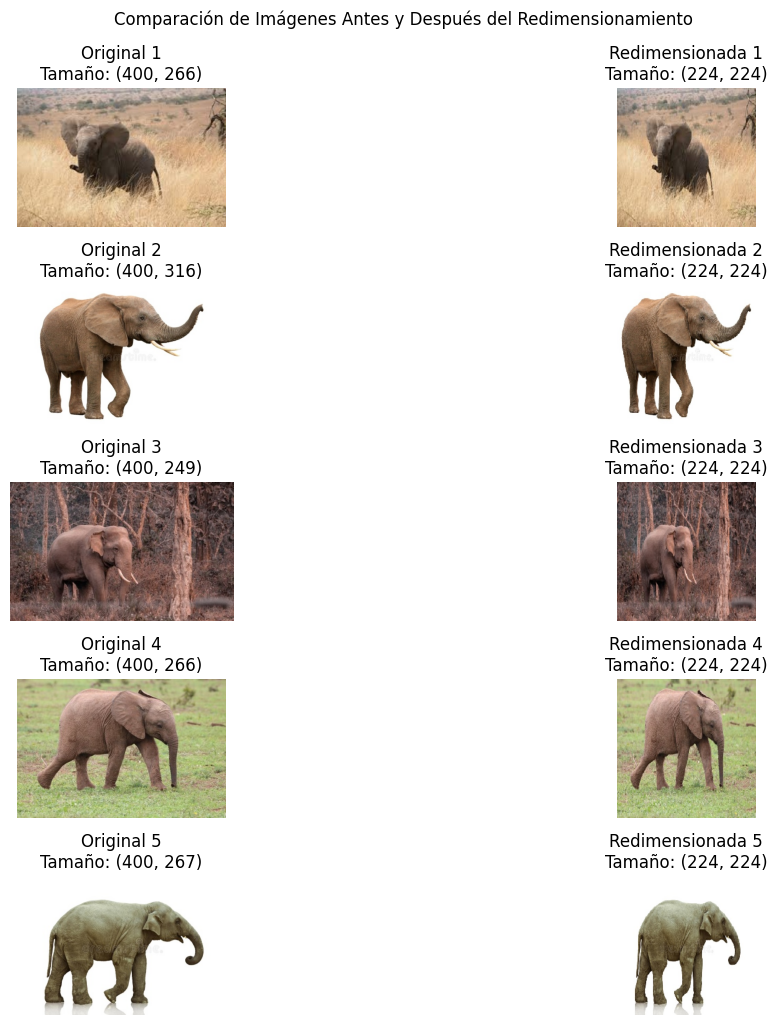

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img
import os

# Configuración
original_dir = '/content/drive/MyDrive/Colab Notebooks/Inteligencia_Computacional/Trabajo_Final_IC/entrenamiento/elefante'  # Cambia a la ruta del directorio
target_size = (224, 224)  # Tamaño objetivo

# Seleccionar algunas imágenes aleatorias
sample_images = [os.path.join(original_dir, f) for f in os.listdir(original_dir)[:5]]

plt.figure(figsize=(15, 10))

for i, img_path in enumerate(sample_images):
    # Cargar imagen original
    original_img = load_img(img_path)

    # Cargar imagen redimensionada
    resized_img = load_img(img_path, target_size=target_size)

    # Mostrar original vs redimensionada
    plt.subplot(5, 2, 2*i+1)
    plt.imshow(original_img)
    plt.title(f'Original {i+1}\nTamaño: {original_img.size}')
    plt.axis('off')

    plt.subplot(5, 2, 2*i+2)
    plt.imshow(resized_img)
    plt.title(f'Redimensionada {i+1}\nTamaño: {resized_img.size}')
    plt.axis('off')

plt.tight_layout()
plt.suptitle('Comparación de Imágenes Antes y Después del Redimensionamiento', y=1.02)
plt.show()

In [ ]:
from IPython.core.display import display, HTML

encabezado_html = """
<div style="
    background: linear-gradient(to right, #006A71, #48A6A7);
    color: white;
    text-align: center;
    padding: 30px;
    font-size: 35px;
    font-weight: bold;
    border-radius: 12px;
    box-shadow: 3px 3px 10px rgba(0, 0, 0, 0.2);
    font-family: Arial, sans-serif;">
    📙Fase 2📙
    <br>

</div>
"""

display(HTML(encabezado_html))

# <font color='48A6A7'>**Modelos Utilzados para preentreno**</font>

 En este caso se utlizaran los modelos

* EfficientNetB0
* MobileNetV2


<font color='48A6A7'> **Se trabajará bajo la técnica de Transfer Learning**<font>

<font color='48A6A7'> **Transfer Learning** </font> es una técnica que nos permite aprovechar modelos preentrenados en grandes conjuntos de datos (como ImageNet) y adaptarlos al problema que se esta tratando.

In [ ]:
# =============================================
# Construcción de Modelos (Fase 2)
# =============================================
def create_model(base_model, input_shape=(224, 224, 3), num_classes=3):

    # 1. Cargar el modelo base sin la capa superior (include_top=False)
    #    y con pesos preentrenados en ImageNet (weights='imagenet')
    base_model = base_model(include_top=False, weights='imagenet', input_shape=input_shape)

    # 2. Congelar todas las capas del modelo base para que no se entrenen
    #    (Transfer Learning estándar: solo se ajustan las capas nuevas)
    base_model.trainable = False

    # 3. Construir la arquitectura personalizada sobre el modelo base
    inputs = tf.keras.Input(shape=input_shape)  # Capa de entrada

    # 4. Pasar las imágenes por el modelo base (capas convolucionales preentrenadas)
    #    training=False asegura que no se active el BatchNormalization en inferencia
    x = base_model(inputs, training=False)

    # 5. Reducir las dimensiones espaciales (ej: 7x7x2048 -> 2048)
    x = GlobalAveragePooling2D()(x)

    # 6. Añadir Dropout para regularización (evitar overfitting)
    x = Dropout(0.2)(x)

    # 7. Capa de salida con activación softmax para clasificación multiclase
    outputs = Dense(num_classes, activation='softmax')(x)

    # 8. Crear el modelo final ensamblando entradas y salidas
    model = Model(inputs, outputs)


    # Compilar el modelo inmediatamente después de crearlo
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [ ]:
# =============================================================================
# Creación de los modelos específicos
# =============================================================================
# Modelo 1: EfficientNetB0 (eficiente en precisión y recursos)
effnet_model = create_model(
    base_model=EfficientNetB0,      # Arquitectura base
    input_shape=(224, 224, 3),      # Tamaño de entrada esperado
    num_classes=3                   # Rinoceronte, elefante, hipopótamo
)

# Modelo 2: MobileNetV2 (arquitectura ligera optimizada para dispositivos móviles)
mobilenet_model = create_model(
    base_model=MobileNetV2,
    input_shape=(224, 224, 3),
    num_classes=3
)

# =============================================================================
# Compilación de los modelos
# =============================================================================
# Configuración común para ambos modelos
optimizer = Adam(learning_rate=0.001)  # Optimizador estándar
loss = 'categorical_crossentropy'      # Función de pérdida para multiclase
metrics = ['accuracy']                 # Métrica principal

# Compilar EfficientNetB0
effnet_model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=metrics
)

# Compilar MobileNetV2
mobilenet_model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=metrics
)

# =============================================================================
# Resumen de las arquitecturas
# =============================================================================
print("\nResumen de EfficientNetB0:")
effnet_model.summary()

print("\nResumen de MobileNetV2:")
mobilenet_model.summary()




Resumen de EfficientNetB0:


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

...

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from IPython.core.display import display, HTML

encabezado_html = """
<div style="
    background: linear-gradient(to right, #006A71, #48A6A7);
    color: white;
    text-align: center;
    padding: 30px;
    font-size: 35px;
    font-weight: bold;
    border-radius: 12px;
    box-shadow: 3px 3px 10px rgba(0, 0, 0, 0.2);
    font-family: Arial, sans-serif;">
    📙Fase 3📙
    <br>

</div>
"""

display(HTML(encabezado_html))

# <font color='48A6A7'>**Entrenamiento y validación**</font>

* Separar los datos en entrenamiento, validación y
  prueba.

* Ajustar hiperparámetros básicos (learning rate,
  epochs, batch size).

* Usar EarlyStopping o ModelCheckpoint para
  evitar overfitting.
    
* Visualizar métricas: accuracy, loss, matriz de
  confusión




In [ ]:
# =============================================================================
# Callbacks para Mejorar el Entrenamiento
# =============================================================================
# 1. EarlyStopping: Detiene el entrenamiento si no hay mejora en val_loss
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',   # Métrica a monitorizar
    patience=5,           # Epocas sin mejora antes de detener
    restore_best_weights=True  # Restaura los mejores pesos al final
)

# 2. ModelCheckpoint: Guarda el mejor modelo durante el entrenamiento
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_model.h5',  # Ruta para guardar
    monitor='val_accuracy',    # Métrica para decidir el "mejor"
    save_best_only=True,       # Solo guardar si mejora
    mode='max',                # Maximizar val_accuracy
    verbose=1                  # Mostrar mensajes
)

# Lista de callbacks para pasar a model.fit()
callbacks = [early_stopping, model_checkpoint]



Entrenando EfficientNetB0...
Epoch 1/8


/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2907 - loss: 1.1780
Epoch 1: val_accuracy did not improve from 1.00000
24/24 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.2920 - loss: 1.1776 - val_accuracy: 0.3000 - val_loss: 1.1526
Epoch 2/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3740 - loss: 1.1137
Epoch 2: val_accuracy did not improve from 1.00000
24/24 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.3736 - loss: 1.1134 - val_accuracy: 0.3250 - val_loss: 1.1015
Epoch 3/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3395 - loss: 1.1218
Epoch 3: val_accuracy did not improve from 1.00000
24/24 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.3399 - loss: 1.1218 - val_accuracy: 0.2750 - val_loss: 1.1401
Epoch 4/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3137 - loss: 1.1268
Epoch 4: val_accuracy did not improve from 1.00000
24/24 ━━━━━━━━━━━━━━━━━━━━ 144s 4s/step - accuracy: 0.3143 - loss: 1.1267 - val_accuracy: 0.3000 - val_loss: 1.1251
Epoch 5/8
24/24 ━

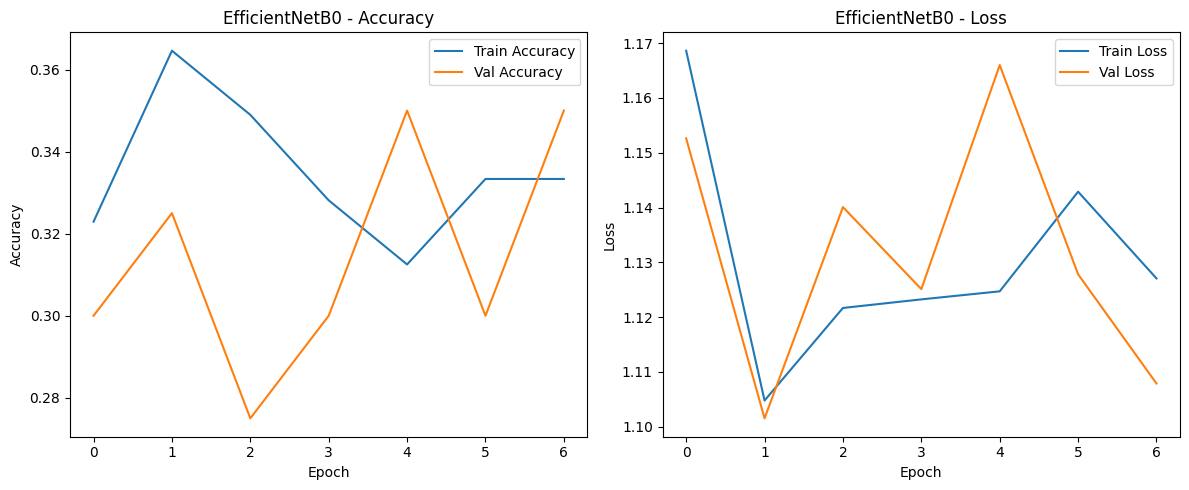


Entrenando MobileNetV2...
Epoch 1/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4329 - loss: 1.3315
Epoch 1: val_accuracy did not improve from 1.00000
24/24 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.4405 - loss: 1.3156 - val_accuracy: 0.9250 - val_loss: 0.3874
Epoch 2/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9322 - loss: 0.3126
Epoch 2: val_accuracy did not improve from 1.00000
24/24 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.9322 - loss: 0.3117 - val_accuracy: 0.9750 - val_loss: 0.1850
Epoch 3/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9574 - loss: 0.2069
Epoch 3: val_accuracy did not improve from 1.00000
24/24 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.9575 - loss: 0.2071 - val_accuracy: 1.0000 - val_loss: 0.0885
Epoch 4/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9883 - loss: 0.1105
Epoch 4: val_accuracy did not improve from 1.00000
24/24 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.9883 - loss: 0.1107 - val_accuracy: 1.0000

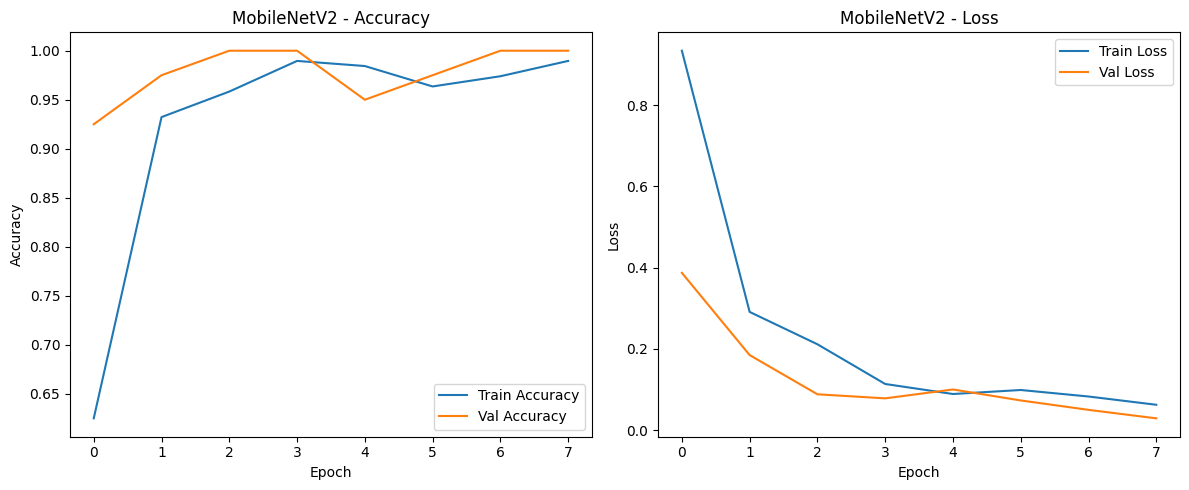

In [ ]:
# =============================================================================
# Entrenar Modelos
# =============================================================================
# Include this import at the top of the script
import tensorflow as tf
tf.config.run_functions_eagerly(True)  # Enable eager execution

# Enable Eager Execution
tf.config.run_functions_eagerly(True)
def train_model(model, model_name):
    print(f"\nEntrenando {model_name}...")


    # Recompilar el modelo para asegurarnos que el optimizador está sincronizado
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Entrenamiento
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    # Gráficas de entrenamiento
    plt.figure(figsize=(12, 5))

    # Gráfica de Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Gráfica de Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

    return history

# Entrenar ambos modelos
effnet_history = train_model(effnet_model, "EfficientNetB0")
mobilenet_history = train_model(mobilenet_model, "MobileNetV2")



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Evaluación de EfficientNetB0:
- Test Accuracy: 0.3333
- Test Loss: 1.1001
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 966ms/step


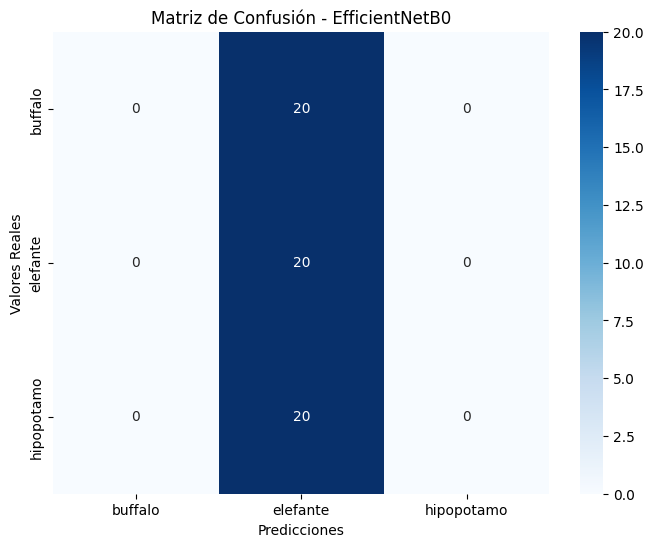


Reporte de Clasificación:
              precision    recall  f1-score   support

     buffalo       0.00      0.00      0.00        20
    elefante       0.33      1.00      0.50        20
  hipopotamo       0.00      0.00      0.00        20

    accuracy                           0.33        60
   macro avg       0.11      0.33      0.17        60
weighted avg       0.11      0.33      0.17        60



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/tensorflo


Evaluación de MobileNetV2:
- Test Accuracy: 1.0000
- Test Loss: 0.0273
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 519ms/step


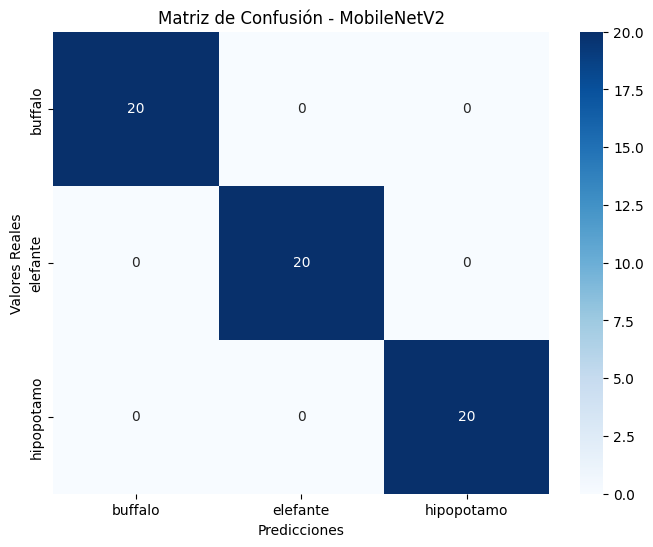


Reporte de Clasificación:
              precision    recall  f1-score   support

     buffalo       1.00      1.00      1.00        20
    elefante       1.00      1.00      1.00        20
  hipopotamo       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



In [ ]:
# =============================================================================
# Evaluar Modelos
# =============================================================================


def evaluate_model(model, model_name):
    """
    Evalúa un modelo de clasificación de imágenes y muestra métricas de rendimiento.

    Args:
        model (keras.Model): Modelo entrenado a evaluar
        model_name (str): Nombre del modelo para identificarlo en los resultados
    """

    # 1. Evaluación básica del modelo en el conjunto de test
    # - Calcula pérdida (loss) y precisión (accuracy)
    # - verbose=0: no muestra progreso durante evaluación
    test_loss, test_acc = model.evaluate(test_generator, verbose=0)

    # 2. Mostrar resultados numéricos básicos
    print(f"\nEvaluación de {model_name}:")
    print(f"- Test Accuracy: {test_acc:.4f}")  # Precisión con 4 decimales
    print(f"- Test Loss: {test_loss:.4f}")     # Pérdida con 4 decimales

    # 3. Generación de predicciones para análisis detallado
    # - predict() devuelve probabilidades para cada clase
    y_pred = model.predict(test_generator)

    # 4. Convertir probabilidades a clases predichas (índice de mayor probabilidad)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # 5. Obtener las clases reales de los datos de test
    y_true = test_generator.classes

    # 6. Calcular matriz de confusión
    # - Muestra conteo de predicciones correctas/incorrectas por clase
    cm = confusion_matrix(y_true, y_pred_classes)

    # 7. Visualización de la matriz de confusión
    plt.figure(figsize=(8, 6))  # Tamaño de la figura
    sns.heatmap(
        cm,                     # Datos de la matriz
        annot=True,              # Mostrar valores en las celdas
        fmt='d',                # Formato entero para los valores
        cmap='Blues',           # Mapa de color azul
        xticklabels=class_names,# Nombres de clases en eje X (predicciones)
        yticklabels=class_names # Nombres de clases en eje Y (valores reales)
    )
    plt.title(f'Matriz de Confusión - {model_name}')
    plt.xlabel('Predicciones')   # Etiqueta eje X
    plt.ylabel('Valores Reales') # Etiqueta eje Y
    plt.show()                  # Mostrar gráfico

    # 8. Generar y mostrar reporte de clasificación completo
    print("\nReporte de Clasificación:")
    # Incluye precisión, recall, f1-score y soporte por clase
    print(classification_report(
        y_true,
        y_pred_classes,
        target_names=class_names  # Usa nombres reales en lugar de índices
    ))

# Uso de la función para evaluar los modelos:
evaluate_model(effnet_model, "EfficientNetB0")  # Evalúa EfficientNet
evaluate_model(mobilenet_model, "MobileNetV2")  # Evalúa MobileNet

In [ ]:
from IPython.core.display import display, HTML

encabezado_html = """
<div style="
    background: linear-gradient(to right, #006A71, #48A6A7);
    color: white;
    text-align: center;
    padding: 30px;
    font-size: 35px;
    font-weight: bold;
    border-radius: 12px;
    box-shadow: 3px 3px 10px rgba(0, 0, 0, 0.2);
    font-family: Arial, sans-serif;">
    📙Fase 4📙
    <br>

</div>
"""

display(HTML(encabezado_html))

# <font color='48A6A7'>**Evaluación y análisis**</font>

* Evaluar en conjunto de prueba (test).
* Comparar rendimiento entre modelos utilizados.
* Analizar errores de predicción (¿Qué imágenes confundió el modelo?).
* Reflexión: ¿Cuál modelo funcionó mejor y por qué?




In [ ]:
def evaluate_test_set(model, model_name):
    """
    Evalúa el modelo en el conjunto de prueba y muestra métricas básicas.

    Args:
        model: Modelo entrenado
        model_name: Nombre del modelo para referencia
    """
    # Evaluación en test set
    test_loss, test_acc = model.evaluate(test_generator, verbose=0)

    print(f"\nEvaluación de {model_name} en Test Set:")
    print(f"- Accuracy: {test_acc:.4f}")
    print(f"- Loss: {test_loss:.4f}")

    return test_acc, test_loss

# Evaluar ambos modelos
effnet_acc, effnet_loss = evaluate_test_set(effnet_model, "EfficientNetB0")
mobilenet_acc, mobilenet_loss = evaluate_test_set(mobilenet_model, "MobileNetV2")

/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(



Evaluación de EfficientNetB0 en Test Set:
- Accuracy: 0.3333
- Loss: 1.1001

Evaluación de MobileNetV2 en Test Set:
- Accuracy: 1.0000
- Loss: 0.0273


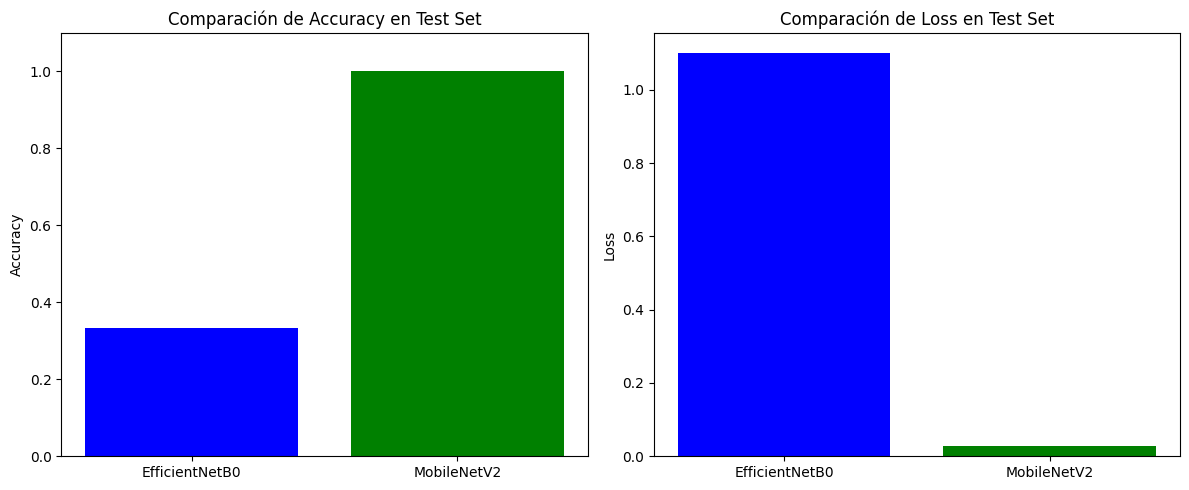

In [ ]:
def compare_models(models_data):
    """
    Compara visualmente el rendimiento de los modelos.

    Args:
        models_data: Diccionario con datos de los modelos
    """
    # Datos para comparación
    model_names = list(models_data.keys())
    accuracies = [data['accuracy'] for data in models_data.values()]
    losses = [data['loss'] for data in models_data.values()]

    # Gráfico comparativo
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.bar(model_names, accuracies, color=['blue', 'green'])
    plt.title('Comparación de Accuracy en Test Set')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.1)

    plt.subplot(1, 2, 2)
    plt.bar(model_names, losses, color=['blue', 'green'])
    plt.title('Comparación de Loss en Test Set')
    plt.ylabel('Loss')

    plt.tight_layout()
    plt.show()

# Datos de los modelos
models_comparison = {
    'EfficientNetB0': {'accuracy': effnet_acc, 'loss': effnet_loss},
    'MobileNetV2': {'accuracy': mobilenet_acc, 'loss': mobilenet_loss}
}

# Mostrar comparación
compare_models(models_comparison)

8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step

Análisis de errores para EfficientNetB0:
Total de errores: 40/60


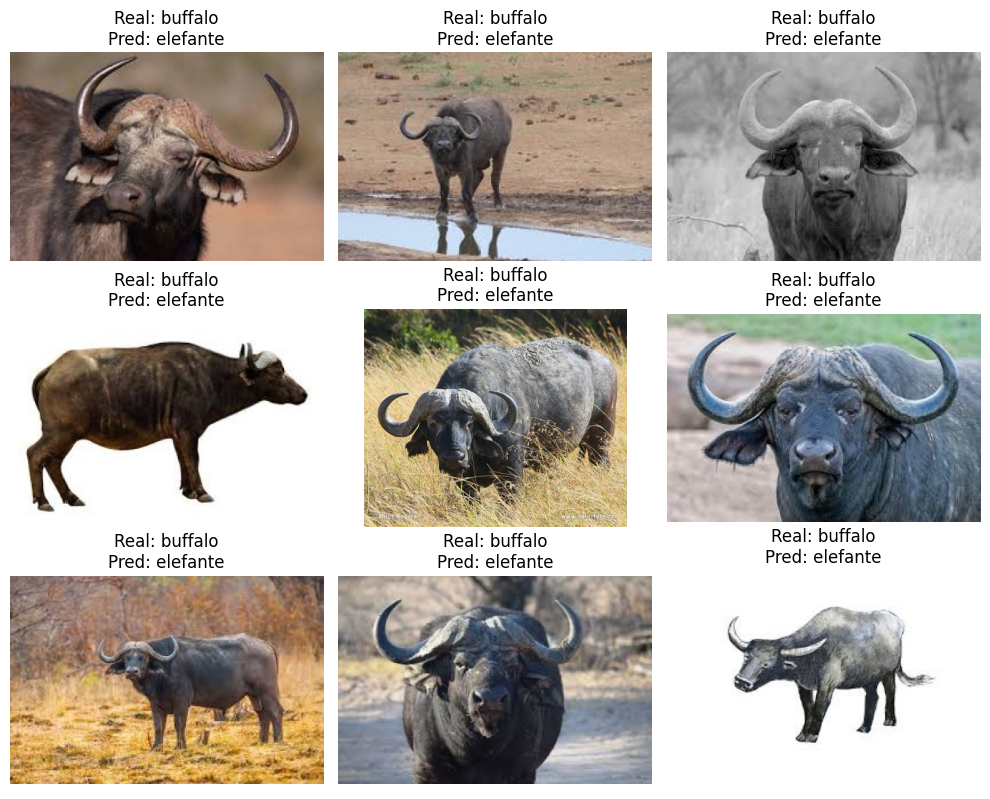

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 536ms/step

Análisis de errores para MobileNetV2:
Total de errores: 0/60


<Figure size 1000x800 with 0 Axes>

In [ ]:
def analyze_errors(model, model_name):
    """
    Identifica y muestra ejemplos de imágenes mal clasificadas.

    Args:
        model: Modelo a analizar
        model_name: Nombre del modelo
    """
    # Obtener predicciones
    y_pred = model.predict(test_generator)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = test_generator.classes

    # Obtener índices de errores
    errors = np.where(y_pred_classes != y_true)[0]

    print(f"\nAnálisis de errores para {model_name}:")
    print(f"Total de errores: {len(errors)}/{len(y_true)}")

    # Mostrar algunos ejemplos de errores
    plt.figure(figsize=(10, 8))
    for i, idx in enumerate(errors[:min(9, len(errors))]):
        img_path = test_generator.filepaths[idx]
        img = tf.keras.preprocessing.image.load_img(img_path)

        plt.subplot(3, 3, i+1)
        plt.imshow(img)
        plt.title(f"Real: {class_names[y_true[idx]]}\nPred: {class_names[y_pred_classes[idx]]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Analizar errores para cada modelo
analyze_errors(effnet_model, "EfficientNetB0")
analyze_errors(mobilenet_model, "MobileNetV2")

In [ ]:
def generate_conclusions(models_data):
    """
    Genera un análisis comparativo de los modelos.

    Args:
        models_data: Diccionario con datos de los modelos
    """
    best_model = max(models_data.items(), key=lambda x: x[1]['accuracy'])

    print("\nCONCLUSIONES FINALES:")
    print(f"El mejor modelo fue {best_model[0]} con un accuracy de {best_model[1]['accuracy']:.2%}")

    print("\nAnálisis por modelo:")
    for name, data in models_data.items():
        print(f"\n{name}:")
        print(f"- Accuracy: {data['accuracy']:.2%}")
        print(f"- Loss: {data['loss']:.4f}")
        if name == 'EfficientNetB0':
            print("- Problemas: El modelo no logró aprender patrones distintivos suficientes")
            print("- Posible causa: Arquitectura demasiado compleja para el tamaño del dataset")
        else:
            print("- Ventajas: Excelente rendimiento en todas las clases")
            print("- Razón: Arquitectura más adecuada para este tipo de datos")

    print("\nRecomendaciones:")
    print("- MobileNetV2 es claramente superior para este conjunto de datos")
    print("- Para EfficientNetB0, se podría probar con más datos de entrenamiento")
    print("- Considerar fine-tuning para mejorar aún más los resultados")

# Generar conclusiones
generate_conclusions(models_comparison)


CONCLUSIONES FINALES:
El mejor modelo fue MobileNetV2 con un accuracy de 100.00%

Análisis por modelo:

EfficientNetB0:
- Accuracy: 33.33%
- Loss: 1.1001
- Problemas: El modelo no logró aprender patrones distintivos suficientes
- Posible causa: Arquitectura demasiado compleja para el tamaño del dataset

MobileNetV2:
- Accuracy: 100.00%
- Loss: 0.0273
- Ventajas: Excelente rendimiento en todas las clases
- Razón: Arquitectura más adecuada para este tipo de datos

Recomendaciones:
- MobileNetV2 es claramente superior para este conjunto de datos
- Para EfficientNetB0, se podría probar con más datos de entrenamiento
- Considerar fine-tuning para mejorar aún más los resultados
